# Final Deliverable

**Author:** Stella Dong

*Department of Computer Science & Engineering, Texas A&M University*  
*This work was completed as part of CSCE 676: Data Mining and Analysis, taught by Prof. James Caverlee.*

The Github repository of this project can be found here: [Github link](https://github.com/stellasdong/676_project/).

--

In [54]:
import sys
print(sys.executable)
!pip install -r requirements.txt

/Users/stelladong/Documents/GitHub/676_project/.venv/bin/python


In [55]:
import warnings
warnings.filterwarnings('ignore')

import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

from icdmappings import Mapper
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Imports complete.')


Imports complete.


In [56]:
DATA_PATH = "/Users/stelladong/Library/CloudStorage/GoogleDrive-ssdong@tamu.edu/My Drive/bcs_tx_inpatient.csv"

bcs_tx_inpatient = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded: {bcs_tx_inpatient.shape[0]:,} rows × {bcs_tx_inpatient.shape[1]} columns")

Loaded: 11,174 rows × 169 columns


In [57]:
df = bcs_tx_inpatient.copy()

# Identify diagnosis columns present in the dataframe
DIAG_COLS = [c for c in
             ['PRINC_DIAG_CODE'] + [f'OTH_DIAG_CODE_{i}' for i in range(1, 25)]
             if c in df.columns]

# Collect all unique ICD-10 codes across all diagnosis columns
all_codes = set()
for col in DIAG_COLS:
    all_codes.update(df[col].dropna().unique())
all_codes = list(all_codes)
print(f"Unique ICD-10 codes in dataset: {len(all_codes):,}")

BATCH_SIZE = 10000
mapper = Mapper()
ccsr_mapping = {}

for i in range(0, len(all_codes), BATCH_SIZE):
    batch = all_codes[i : i + BATCH_SIZE]
    results = mapper.map(batch, source='icd10', target='ccsr')
    for code, ccsr in zip(batch, results):
        ccsr_mapping[code] = ccsr  # None if unmappable

mapped = sum(1 for v in ccsr_mapping.values() if v is not None)
print(f"CCSR coverage: {mapped:,} / {len(ccsr_mapping):,} "
      f"({mapped / len(ccsr_mapping) * 100:.1f}%)")

Unique ICD-10 codes in dataset: 5,571
CCSR coverage: 5,571 / 5,571 (100.0%)


In [58]:
# --- Association Rule Mining on CCSR comorbidities ---

# Build transactions: each patient is a "basket" of CCSR categories
def get_ccsr_set(row):
    cats = set()
    for col in DIAG_COLS:
        code = row[col]
        if pd.notna(code):
            ccsr = ccsr_mapping.get(code)
            if ccsr is not None:
                cats.add(ccsr)
    return list(cats)

ccsr_transactions = df.apply(get_ccsr_set, axis=1).tolist()
# Drop patients with no mappable codes
ccsr_transactions = [t for t in ccsr_transactions if len(t) > 0]
print(f"Transactions: {len(ccsr_transactions):,} patients")
print(f"Avg CCSR categories per patient: {np.mean([len(t) for t in ccsr_transactions]):.1f}")

# Encode as boolean DataFrame for mlxtend
te = TransactionEncoder()
te_array = te.fit_transform(ccsr_transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)
print(f"Item set size: {df_te.shape[1]} unique CCSR categories")

# --- Frequent itemsets (min_support tunable) ---
MIN_SUPPORT = 0.05   # at least 5% of patients
frequent_itemsets = apriori(df_te, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f"\nFrequent itemsets (support ≥ {MIN_SUPPORT}): {len(frequent_itemsets):,}")
print(frequent_itemsets.sort_values('support', ascending=False).head(10).to_string(index=False))

# --- Association rules ---
MIN_CONFIDENCE = 0.5
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
print(f"\nAssociation rules (confidence ≥ {MIN_CONFIDENCE}): {len(rules):,}")


Transactions: 11,174 patients
Avg CCSR categories per patient: 10.3
Item set size: 439 unique CCSR categories

Frequent itemsets (support ≥ 0.05): 450
 support         itemsets  length
0.582692         (FAC025)       1
0.416771         (FAC021)       1
0.349025         (END010)       1
0.317791 (FAC021, FAC025)       2
0.289601         (CIR008)       1
0.280562 (END010, FAC025)       2
0.273313         (CIR007)       1
0.237337 (CIR008, FAC025)       2
0.229640         (CIR011)       1
0.222839         (END009)       1

Association rules (confidence ≥ 0.5): 929


In [59]:
# --- Load CCSR descriptions ---
CCSR_DESC_PATH = "/Users/stelladong/Documents/GitHub/676_project/ccsr_descriptions.txt"

ccsr_desc = {}
with open(CCSR_DESC_PATH) as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            ccsr_desc[parts[0]] = parts[1]

print(f"Loaded {len(ccsr_desc):,} CCSR descriptions")

def fmt_codes(frozen_set):
    return ' | '.join(f"{c} ({ccsr_desc.get(c, c)})" for c in sorted(frozen_set))

# Re-display top 30 rules with human-readable descriptions
top30 = (rules[rules['antecedents'].apply(len) == 1]
         .head(30)
         [['antecedents', 'consequents', 'support', 'confidence', 'lift']]
         .copy())

top30['antecedent_desc'] = top30['antecedents'].apply(fmt_codes)
top30['consequent_desc'] = top30['consequents'].apply(fmt_codes)

display_cols = ['antecedent_desc', 'consequent_desc', 'support', 'confidence', 'lift']
print("\nTop 30 comorbidity rules (single antecedent, ranked by lift):\n")
print(top30[display_cols].to_string(index=False))

Loaded 520 CCSR descriptions

Top 30 comorbidity rules (single antecedent, ranked by lift):

                                                            antecedent_desc                                                                                                                  consequent_desc  support  confidence     lift
                           PRG026 (OB-related trauma to perineum and vulva)                                                               PRG002 (Gestational weeks) | PRG030 (Maternal outcome of delivery) 0.057276    0.993789 7.412948
                           PRG026 (OB-related trauma to perineum and vulva)                                                                                            PRG030 (Maternal outcome of delivery) 0.057544    0.998447 7.408134
           PRG024 (Malposition, disproportion or other labor complications)                                                                                            PRG030 (Maternal outcome of deliver

In [60]:
# --- Export high-scoring comorbidity rules to CSV ---

# Fix CCSR description lookup: map code -> description
CCSR_DESC_PATH = "/Users/stelladong/Documents/GitHub/676_project/ccsr_descriptions.txt"
ccsr_desc_fixed = {}
with open(CCSR_DESC_PATH) as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            ccsr_desc_fixed[parts[0]] = parts[1]

def describe_set(frozen_set):
    return ' | '.join(f"{c}: {ccsr_desc_fixed.get(c, c)}" for c in sorted(frozen_set))

# Filter to high-scoring rules: lift >= 2.0 (strong association)
HIGH_LIFT = 2.0
high_score_rules = rules[rules['lift'] >= HIGH_LIFT].copy()

# Flatten frozensets and add human-readable descriptions
high_score_rules['antecedent_codes']  = high_score_rules['antecedents'].apply(lambda s: ' | '.join(sorted(s)))
high_score_rules['antecedent_labels'] = high_score_rules['antecedents'].apply(describe_set)
high_score_rules['consequent_codes']  = high_score_rules['consequents'].apply(lambda s: ' | '.join(sorted(s)))
high_score_rules['consequent_labels'] = high_score_rules['consequents'].apply(describe_set)

export_cols = [
    'antecedent_codes', 'antecedent_labels',
    'consequent_codes', 'consequent_labels',
    'support', 'confidence', 'lift',
]
export_df = (high_score_rules[export_cols]
             .sort_values('lift', ascending=False)
             .reset_index(drop=True))

# Round metrics for readability
export_df[['support', 'confidence', 'lift']] = export_df[['support', 'confidence', 'lift']].round(4)

OUT_PATH = "/Users/stelladong/Documents/GitHub/676_project/comorbidity_rules.csv"
export_df.to_csv(OUT_PATH, index=False)

print(f"Exported {len(export_df):,} high-scoring rules (lift ≥ {HIGH_LIFT}) → {OUT_PATH}")
print(f"\nPreview (top 10):")
display(export_df.head(10))

Exported 516 high-scoring rules (lift ≥ 2.0) → /Users/stelladong/Documents/GitHub/676_project/comorbidity_rules.csv

Preview (top 10):


,antecedent_codes,antecedent_labels,consequent_codes,consequent_labels,support,confidence,lift
0,PRG002 | PRG026,PRG002: Gestational weeks | PRG026: OB-related...,PRG030,PRG030: Maternal outcome of delivery,0.0573,1.0000,7.4197
1,PRG026,PRG026: OB-related trauma to perineum and vulva,PRG002 | PRG030,PRG002: Gestational weeks | PRG030: Maternal o...,0.0573,0.9938,7.4129
2,PRG026,PRG026: OB-related trauma to perineum and vulva,PRG030,PRG030: Maternal outcome of delivery,0.0575,0.9984,7.4081
3,PRG002 | PRG024,PRG002: Gestational weeks | PRG024: Malpositio...,PRG030,PRG030: Maternal outcome of delivery,0.0524,0.9949,7.3818
4,PRG024,"PRG024: Malposition, disproportion or other la...",PRG030,PRG030: Maternal outcome of delivery,0.0527,0.9933,7.3696
5,PRG002 | PRG023,PRG002: Gestational weeks | PRG023: Complicati...,PRG030,PRG030: Maternal outcome of delivery,0.0729,0.9927,7.3654
6,PRG030,PRG030: Maternal outcome of delivery,PRG002 | PRG023,PRG002: Gestational weeks | PRG023: Complicati...,0.0729,0.5412,7.3654
7,PRG024,"PRG024: Malposition, disproportion or other la...",PRG002 | PRG030,PRG002: Gestational weeks | PRG030: Maternal o...,0.0524,0.9865,7.3586
8,PRG002 | PRG030,PRG002: Gestational weeks | PRG030: Maternal o...,PRG023,PRG023: Complications specified during childbirth,0.0729,0.5441,7.3510
9,PRG023,PRG023: Complications specified during childbirth,PRG002 | PRG030,PRG002: Gestational weeks | PRG030: Maternal o...,0.0729,0.9855,7.3510


In [61]:
# --- Export rules excluding those where PRG/PNL codes appear in BOTH antecedent AND consequent ---

def has_prg_or_pnl(frozen_set):
    return any(c.startswith('PRG') or c.startswith('PNL') for c in frozen_set)

# Exclude rules where ANY PRG/PNL code appears on both sides
mask = ~(high_score_rules['antecedents'].apply(has_prg_or_pnl) &
         high_score_rules['consequents'].apply(has_prg_or_pnl))

filtered_rules = high_score_rules[mask].copy()

export_df_filtered = (filtered_rules[export_cols]
                      .sort_values('lift', ascending=False)
                      .reset_index(drop=True))
export_df_filtered[['support', 'confidence', 'lift']] = export_df_filtered[['support', 'confidence', 'lift']].round(4)

OUT_PATH_FILTERED = "/Users/stelladong/Documents/GitHub/676_project/comorbidity_rules_no_prg_pnl.csv"
export_df_filtered.to_csv(OUT_PATH_FILTERED, index=False)

print(f"Original rules: {len(export_df):,}")
print(f"After excluding rules with PRG/PNL on both sides: {len(export_df_filtered):,} rules → {OUT_PATH_FILTERED}")
print(f"\nPreview (top 10):")
display(export_df_filtered.head(10))

Original rules: 516
After excluding rules with PRG/PNL on both sides: 487 rules → /Users/stelladong/Documents/GitHub/676_project/comorbidity_rules_no_prg_pnl.csv

Preview (top 10):


,antecedent_codes,antecedent_labels,consequent_codes,consequent_labels,support,confidence,lift
0,PNL001 | PNL007,PNL001: Liveborn | PNL007: Hemolytic jaundice ...,FAC016,"FAC016: Exposure, encounters, screening or con...",0.0952,0.9708,4.9129
1,PNL001,PNL001: Liveborn,FAC016,"FAC016: Exposure, encounters, screening or con...",0.1307,0.9688,4.9029
2,FAC016,"FAC016: Exposure, encounters, screening or con...",PNL001,PNL001: Liveborn,0.1307,0.6612,4.9029
3,END010 | FAC025 | GEN003,END010: Disorders of lipid metabolism | FAC025...,CIR008 | END003,CIR008: Hypertension with complications and se...,0.0618,0.5901,4.8483
4,CIR008 | END003,CIR008: Hypertension with complications and se...,END010 | FAC025 | GEN003,END010: Disorders of lipid metabolism | FAC025...,0.0618,0.5081,4.8483
5,CIR008 | CIR011 | FAC025,CIR008: Hypertension with complications and se...,CIR019 | END010,CIR019: Heart failure | END010: Disorders of l...,0.0622,0.5253,4.8472
6,CIR019 | END010,CIR019: Heart failure | END010: Disorders of l...,CIR008 | CIR011 | FAC025,CIR008: Hypertension with complications and se...,0.0622,0.5739,4.8472
7,CIR019 | END010,CIR019: Heart failure | END010: Disorders of l...,CIR008 | CIR011,CIR008: Hypertension with complications and se...,0.0740,0.6829,4.8419
8,CIR008 | CIR011,CIR008: Hypertension with complications and se...,CIR019 | END010,CIR019: Heart failure | END010: Disorders of l...,0.0740,0.5247,4.8419
9,CIR019 | END010 | FAC025,CIR019: Heart failure | END010: Disorders of l...,CIR008 | CIR011,CIR008: Hypertension with complications and se...,0.0622,0.6814,4.8310


In [62]:
# --- Binary CCSR encoding ---
# For each patient (row), collect the set of CCSR categories present across
# all diagnosis columns, then one-hot encode into a binary matrix.

def get_ccsr_set(row):
    cats = set()
    for col in DIAG_COLS:
        code = row[col]
        if pd.notna(code):
            ccsr = ccsr_mapping.get(code)
            if ccsr is not None:
                cats.add(ccsr)
    return list(cats)

# Build list-of-lists: one entry per patient
ccsr_lists = df.apply(get_ccsr_set, axis=1).tolist()

# Fit MultiLabelBinarizer on all observed CCSR categories
mlb = MultiLabelBinarizer()
X_ccsr_binary = mlb.fit_transform(ccsr_lists)

print(f"Binary CCSR matrix shape: {X_ccsr_binary.shape}")
print(f"  Patients : {X_ccsr_binary.shape[0]:,}")
print(f"  CCSR categories : {X_ccsr_binary.shape[1]:,}")
print(f"  Sparsity: {1 - X_ccsr_binary.mean():.1%}")
print(f"\nCCSR category names (first 10): {mlb.classes_[:10].tolist()}")


Binary CCSR matrix shape: (11174, 439)
  Patients : 11,174
  CCSR categories : 439
  Sparsity: 97.7%

CCSR category names (first 10): ['BLD001', 'BLD002', 'BLD003', 'BLD004', 'BLD005', 'BLD006', 'BLD007', 'BLD008', 'BLD010', 'CIR001']


In [63]:
!pip install -q scikit-learn-extra

Computing Sørensen distance matrix...
Distance matrix shape: (11174, 11174)
k= 3  inertia=6,472.5971  silhouette=0.1808
k= 4  inertia=5,836.9730  silhouette=0.1921
k= 5  inertia=5,788.1634  silhouette=0.1692
k= 6  inertia=5,730.5478  silhouette=0.1274
k= 7  inertia=5,580.2195  silhouette=0.1311
k= 8  inertia=5,533.7950  silhouette=0.1529
k= 9  inertia=5,460.9098  silhouette=0.1528
k=10  inertia=5,441.6713  silhouette=0.1523
k=11  inertia=5,387.6158  silhouette=0.1178
k=12  inertia=5,399.7647  silhouette=0.1212


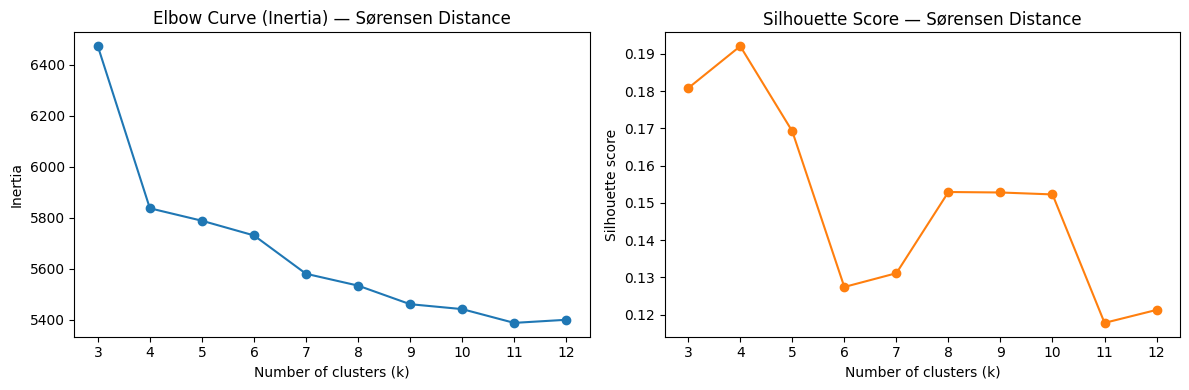

In [64]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform

# Precompute full pairwise Sørensen (Dice) distance matrix once
print("Computing Sørensen distance matrix...")
sorensen_dist = squareform(pdist(X_ccsr_binary, metric='dice'))
print(f"Distance matrix shape: {sorensen_dist.shape}")

K_MIN = 3
K_MAX = 12

inertias = []
silhouette_scores = []
k_range = range(K_MIN, K_MAX + 1)

for k in k_range:
    km = KMedoids(n_clusters=k, metric='precomputed', random_state=RANDOM_SEED, init='k-medoids++')
    labels = km.fit_predict(sorensen_dist)
    inertias.append(km.inertia_)
    sil = silhouette_score(sorensen_dist, labels, metric='precomputed')
    silhouette_scores.append(sil)
    print(f"k={k:2d}  inertia={km.inertia_:,.4f}  silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Curve (Inertia) — Sørensen Distance')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='tab:orange')
axes[1].set_title('Silhouette Score — Sørensen Distance')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()
